# 04 · Retrieval & evaluation

End-to-end search with the saved FAISS index, the ablation results and (optionally) the metric-learning comparison.

Requires `build_embeddings.py`, `build_index.py` and `evaluate.py`.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import src  # noqa: F401  (sets macOS OpenMP workaround before torch/faiss)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils.config import load_config
config = load_config()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "axes.axisbelow": True})
SAME, DIFF = "#2a78d6", "#eb6834"  # fixed categorical slots 1 and 2

In [2]:
from src.retrieval.search import ProductSearchEngine
from src.data.preprocessing import load_image
engine = ProductSearchEngine.from_artifacts(config)
q = engine.product('P0020')
print('query:', q['title'], '|', q['label_group'])
results = engine.search(image=load_image(q['image_file']), title=q['title'], mode='multimodal', top_k=6)
pd.DataFrame([{**r.to_dict(), 'label_group': engine.product(r.product_id)['label_group']} for r in results])[['rank', 'product_id', 'label_group', 'title', 'image_similarity', 'text_similarity', 'combined_similarity', 'is_match']]

query: New Casa Bella CA-MU117 Mug - Green | mug_green


,rank,product_id,label_group,title,image_similarity,text_similarity,combined_similarity,is_match
0,1,P0020,mug_green,New Casa Bella CA-MU117 Mug - Green,1.0000,1.0000,1.0000,True
1,2,P0016,mug_red,[PROMO] Mug Casa Bella Red CA-MU103 free shipping,0.8034,0.9060,0.8444,False
2,3,P0021,mug_green,[PROMO] Coffee Cup Casa Bella Green CA-MU117 f...,0.8481,0.8198,0.8368,False
3,4,P0015,mug_red,New Casa Bella CA-MU103 Ceramic Coffee Mug - Red,0.8075,0.8076,0.8075,False
4,5,P0017,mug_blue,New Casa Bella CA-MU110 Ceramic Coffee Mug - Blue,0.7772,0.8233,0.7957,False
5,6,P0019,mug_blue,casa bella blue mug 350ml - original,0.7863,0.7739,0.7814,False


## Ablation (test queries, threshold tuned on train groups)

In [3]:
from IPython.display import Markdown, Image as IPImage, display
display(Markdown((ROOT / 'artifacts/results/ablation.md').read_text()))

<!-- generated by scripts/evaluate.py; test queries=44, split=group_shuffle, seed=42 -->
| Experiment | R@1 | R@5 | R@10 | mAP@10 | Thr (train) | Precision | Recall | F1 | Query F1 |
|---|---|---|---|---|---|---|---|---|---|
| Image only | 0.322 | 0.564 | 0.735 | 0.485 | 0.90 | 0.212 | 0.391 | 0.275 | 0.287 |
| Text only | 0.261 | 0.723 | 0.951 | 0.551 | 0.70 | 0.302 | 0.739 | 0.429 | 0.421 |
| Image + Text concat | 0.254 | 0.758 | 0.932 | 0.542 | 0.80 | 0.343 | 0.652 | 0.449 | 0.461 |
| Weighted fusion | 0.277 | 0.723 | 0.898 | 0.538 | 0.85 | 0.306 | 0.370 | 0.335 | 0.294 |
| Weighted score fusion | 0.284 | 0.742 | 0.939 | 0.566 | 0.85 | 0.396 | 0.391 | 0.393 | 0.345 |


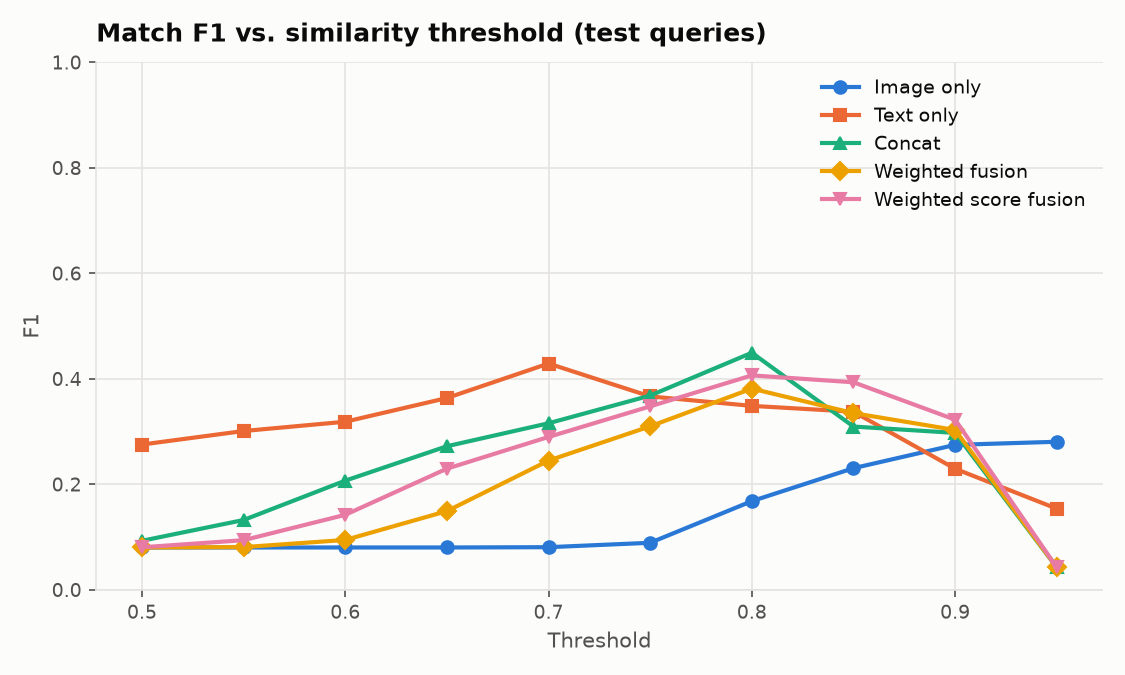

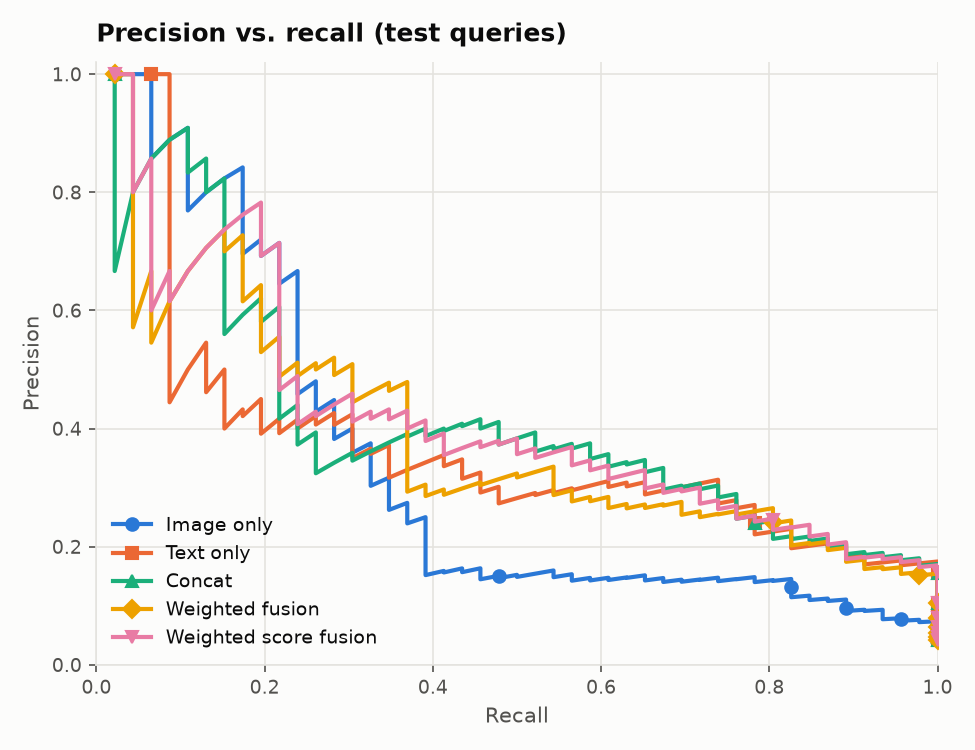

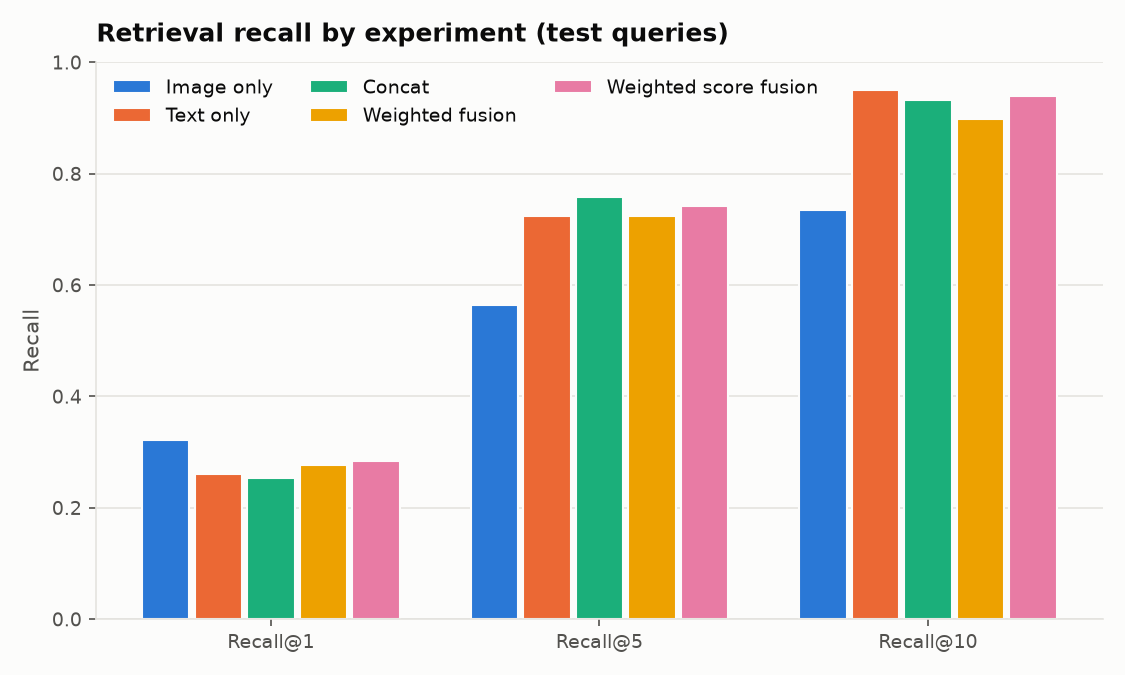

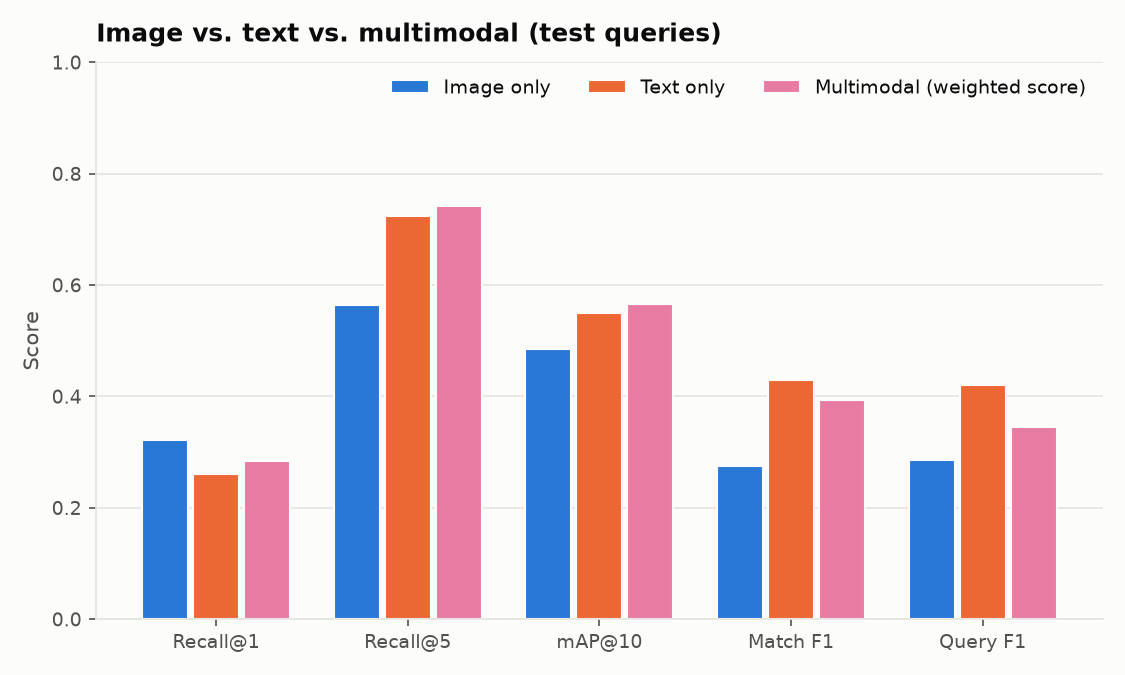

In [4]:
for name in ['threshold_vs_f1', 'precision_recall', 'recall_at_k', 'modality_comparison']:
    display(IPImage(filename=str(ROOT / f'artifacts/plots/{name}.png'), width=640))

## Optional: metric learning
Run `python -m src.training.train_metric_learning` to populate this.

In [5]:
import json
p = ROOT / 'artifacts/results/metric_learning.json'
if p.is_file():
    rep = json.loads(p.read_text())
    rows = [{'modality': m, 'metric': k, 'before': rep['before'][m][k], 'after': rep['after'][m][k]}
            for m in rep['before'] for k in rep['before'][m] if k.startswith(('recall@', 'map@'))]
    display(pd.DataFrame(rows).round(3))
else:
    print('metric learning has not been run')

,modality,metric,before,after
0,image,recall@1,0.322,0.545
1,image,recall@5,0.564,1.000
2,image,recall@10,0.735,1.000
3,image,map@10,0.485,0.997
4,text,recall@1,0.261,0.545
5,text,recall@5,0.723,0.989
6,text,recall@10,0.951,1.000
7,text,map@10,0.551,0.985
8,multimodal,recall@1,0.284,0.545
9,multimodal,recall@5,0.742,1.000
